# Análise Estatística
## Análise de Dados de Compliance Pública - Tese de MBA

**Objetivo:** Realizar análise estatística rigorosa:
- Análise de correlação
- Testes de hipóteses
- Regressão linear múltipla
- Diagnósticos e validação do modelo

In [77]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro, normaltest, jarque_bera

from src.analysis.data_loader import GoldDataLoader

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)


In [78]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


## 1. Carregar Dados

In [79]:
loader = GoldDataLoader(
    bucket_name="enok-mba-thesis-datalake",
    aws_profile="mba-thesis"
)

df = loader.load_dataset('analysis_compliance')
print(f"Carregados {len(df)} observações (estados)")
df.head()

2026-02-09 03:01:10,601 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2026-02-09 03:01:10,798 - INFO - 📥 Loading analysis_compliance from S3: gold/analysis_compliance/data.parquet
2026-02-09 03:01:11,652 - INFO - ✅ Loaded 27 records, 21 columns


Carregados 27 observações (estados)


,state_code,state_name,region_code,region_name,n_municipalities,population,avg_literacy_rate,avg_income,n_sanctions,n_sanctions_ceis,n_sanctions_cnep,n_sanctions_ceaf,n_sanctions_cepim,sanctions_per_100k,log_population,log_income,is_norte,is_nordeste,is_sudeste,is_sul,is_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.2900,1211.9600,0,0,0,0,0,0.0000,14.2737,7.1000,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.4100,778.4900,1,1,0,0,0,0.1205,13.6292,6.6574,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.9600,625.4400,0,0,0,0,0,0.0000,15.1871,6.4385,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.7000,724.2000,0,0,0,0,0,0.0000,13.3641,6.5851,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.8400,764.4600,1,1,0,0,0,0.0123,15.9099,6.6392,1,0,0,0,0


## 2. Análise de Correlação

### 2.1 Pearson Matriz de Correlação

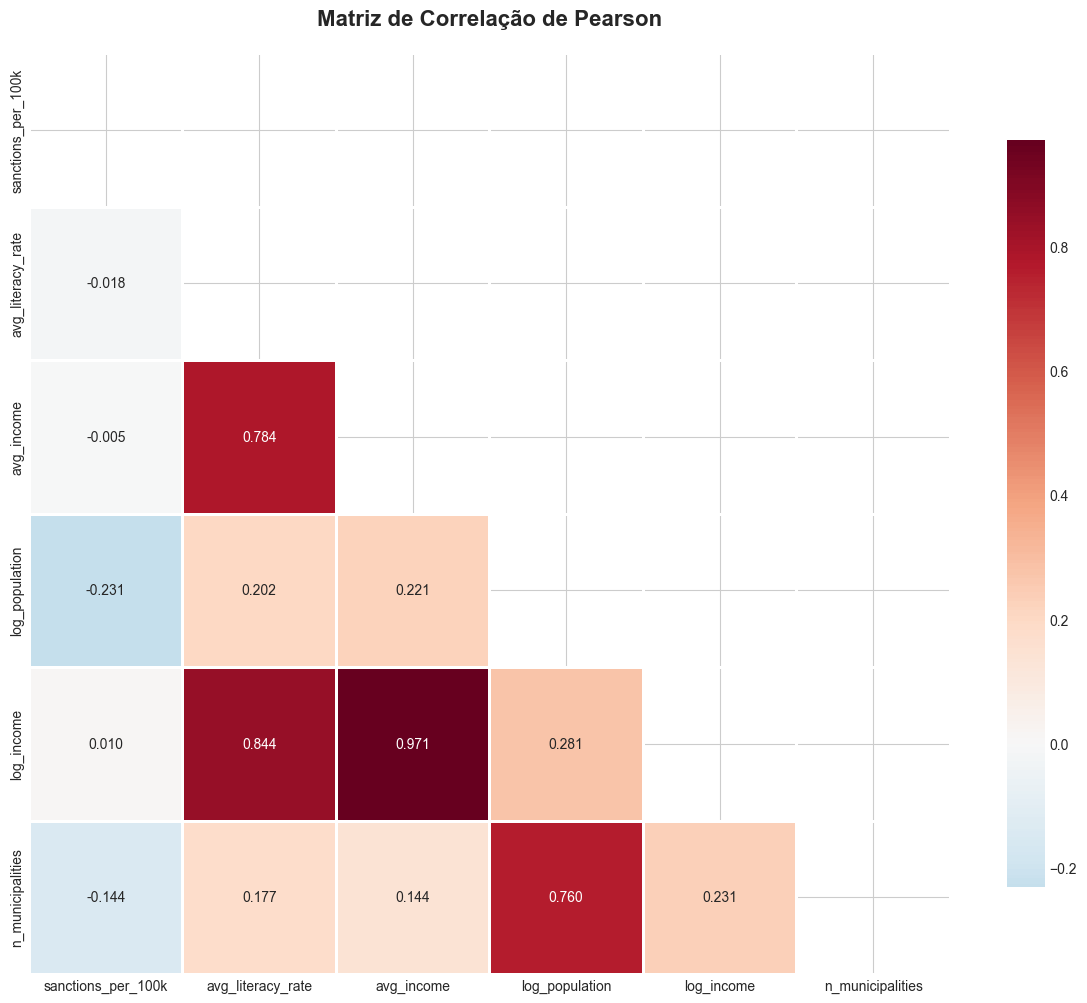


Correlações com Sanções por 100 mil:
sanctions_per_100k    1.0000
log_income            0.0099
avg_income           -0.0048
avg_literacy_rate    -0.0179
n_municipalities     -0.1439
log_population       -0.2305
Name: sanctions_per_100k, dtype: float64


In [80]:
key_vars = ['sanctions_per_100k', 'avg_literacy_rate', 'avg_income', 
            'log_population', 'log_income', 'n_municipalities']

corr_matrix = df[key_vars].corr(method='pearson')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação de Pearson', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelações com Sanções por 100 mil:")
print("=" * 60)
sanctions_corr = corr_matrix['sanctions_per_100k'].sort_values(ascending=False)
print(sanctions_corr)

### 2.2 Teste de Significância Estatística

In [81]:
from scipy.stats import pearsonr

def correlation_test(x, y, var_names):
    """Calcula correlação de Pearson com valor-p."""
    clean_data = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(clean_data) < 3:
        return None, None
    r, p = pearsonr(clean_data['x'], clean_data['y'])
    return r, p

results = []
target = df['sanctions_per_100k']

for var in ['avg_literacy_rate', 'avg_income', 'log_income', 'log_population', 'n_municipalities']:
    r, p = correlation_test(target, df[var], (var, 'sanctions_per_100k'))
    if r is not None:
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        results.append({
            'Variável': var,
            'Correlação (r)': f"{r:.4f}",
            'Valor-p': f"{p:.4f}",
            'Significância': sig
        })

corr_results = pd.DataFrame(results)
print("\nTestes de Correlação com Sanções por 100 mil")
print("=" * 80)
print("Significância: *** p<0.001, ** p<0.01, * p<0.05, ns = não significativo")
print("=" * 80)
display(corr_results)


Testes de Correlação com Sanções por 100 mil
Significância: *** p<0.001, ** p<0.01, * p<0.05, ns = não significativo


,Variável,Correlação (r),Valor-p,Significância
0,avg_literacy_rate,-0.0179,0.9295,ns
1,avg_income,-0.0048,0.9809,ns
2,log_income,0.0099,0.9611,ns
3,log_population,-0.2305,0.2473,ns
4,n_municipalities,-0.1439,0.4738,ns


### 2.3 Gráficos de Dispersão com Linhas de Regressão

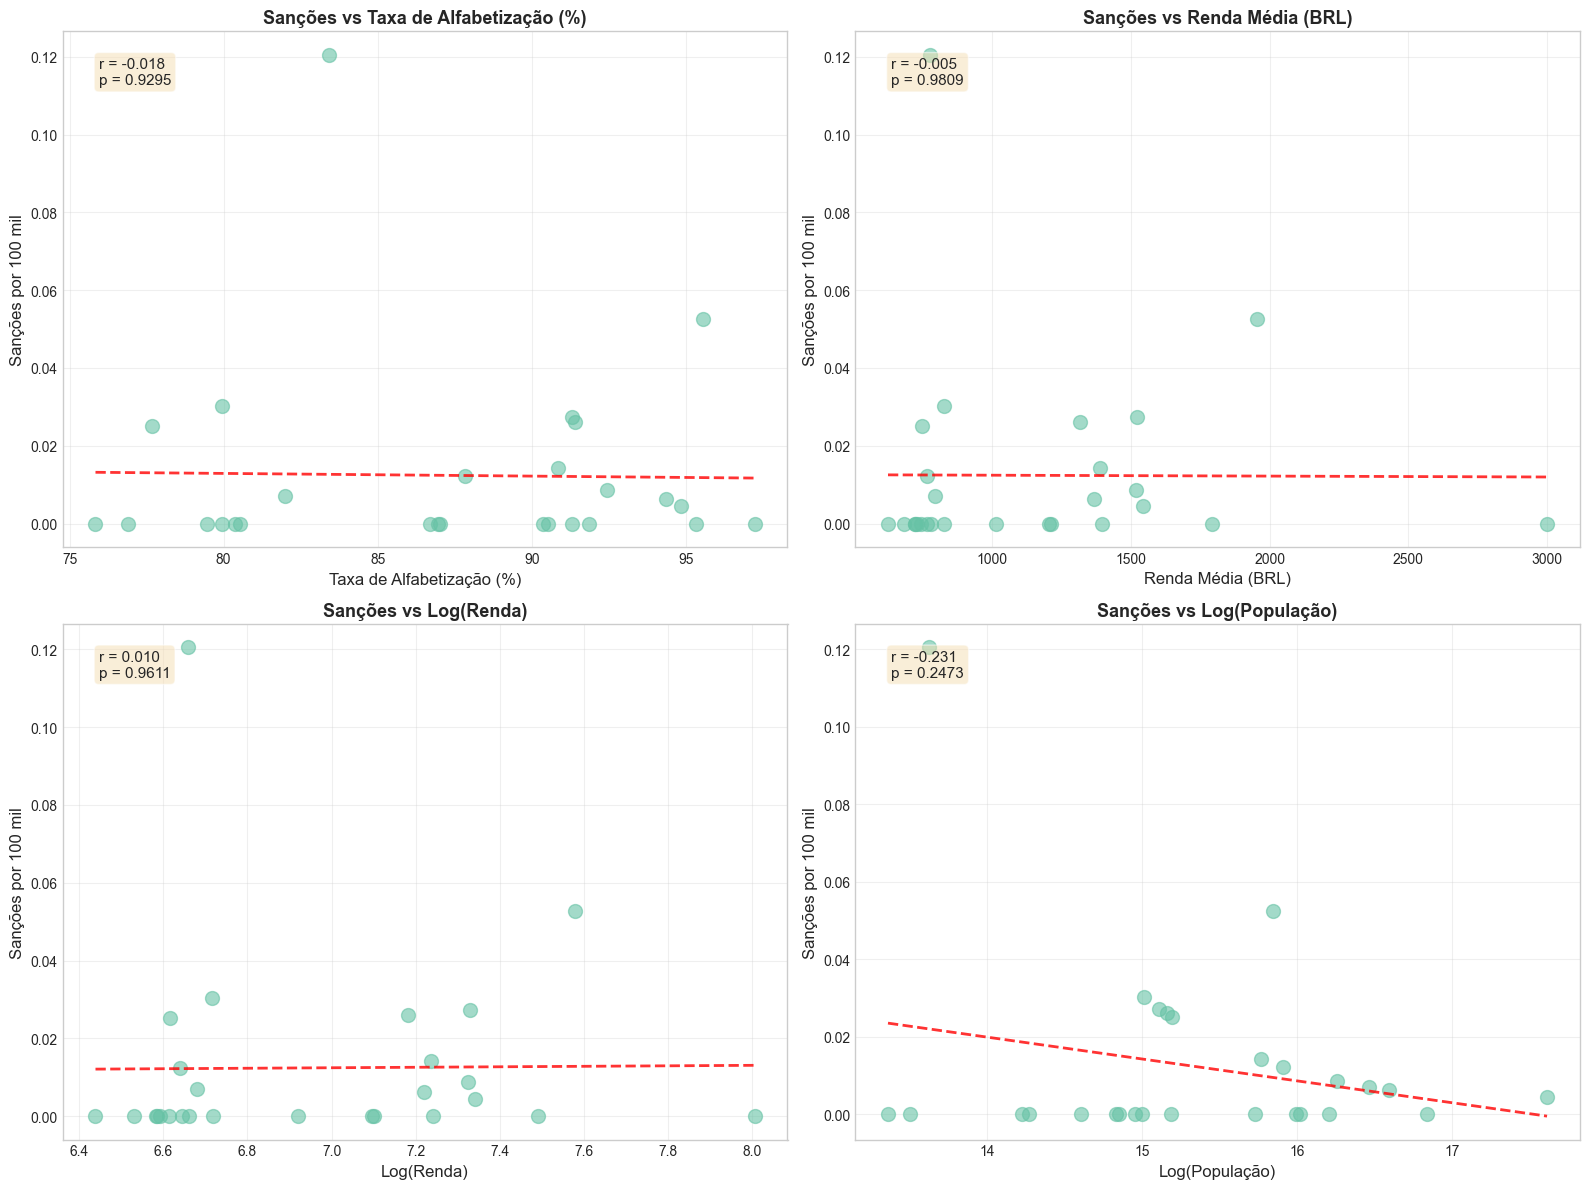

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

vars_to_plot = [
    ('avg_literacy_rate', 'Taxa de Alfabetização (%)', axes[0, 0]),
    ('avg_income', 'Renda Média (BRL)', axes[0, 1]),
    ('log_income', 'Log(Renda)', axes[1, 0]),
    ('log_population', 'Log(População)', axes[1, 1])
]

for var, label, ax in vars_to_plot:
    ax.scatter(df[var], df['sanctions_per_100k'], alpha=0.6, s=100)
    
    z = np.polyfit(df[var].dropna(), df['sanctions_per_100k'][df[var].notna()], 1)
    p = np.poly1d(z)
    ax.plot(df[var].sort_values(), p(df[var].sort_values()), "r--", alpha=0.8, linewidth=2)
    
    r, pval = correlation_test(df[var], df['sanctions_per_100k'], (var, 'sanctions'))
    ax.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.4f}', 
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Sanções por 100 mil', fontsize=12)
    ax.set_title(f'Sanções vs {label}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Testes de Hipótese

### 3.1 Diferenças Regionais (ANOVA)

In [83]:
from scipy.stats import f_oneway

regions = df['region_name'].unique()
groups = [df[df['region_name'] == region]['sanctions_per_100k'].dropna() for region in regions]

f_stat, p_value = f_oneway(*groups)

print("ANOVA One-Way: Diferenças Regionais em Sanções por 100 mil")
print("=" * 70)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nResultado: {'Significativo' if p_value < 0.05 else 'Não significativo'} diferenças regionais")
print("\nMédias Regionais:")
print(df.groupby('region_name')['sanctions_per_100k'].agg(['mean', 'std', 'count']).round(2))

ANOVA One-Way: Diferenças Regionais em Sanções por 100 mil
F-statistic: 0.2850
P-value: 0.8846

Resultado: Não significativo diferenças regionais

Médias Regionais:
               mean    std  count
region_name                      
Centro-Oeste 0.0100 0.0100      4
Nordeste     0.0100 0.0100      9
Norte        0.0200 0.0500      7
Sudeste      0.0100 0.0100      4
Sul          0.0200 0.0300      3


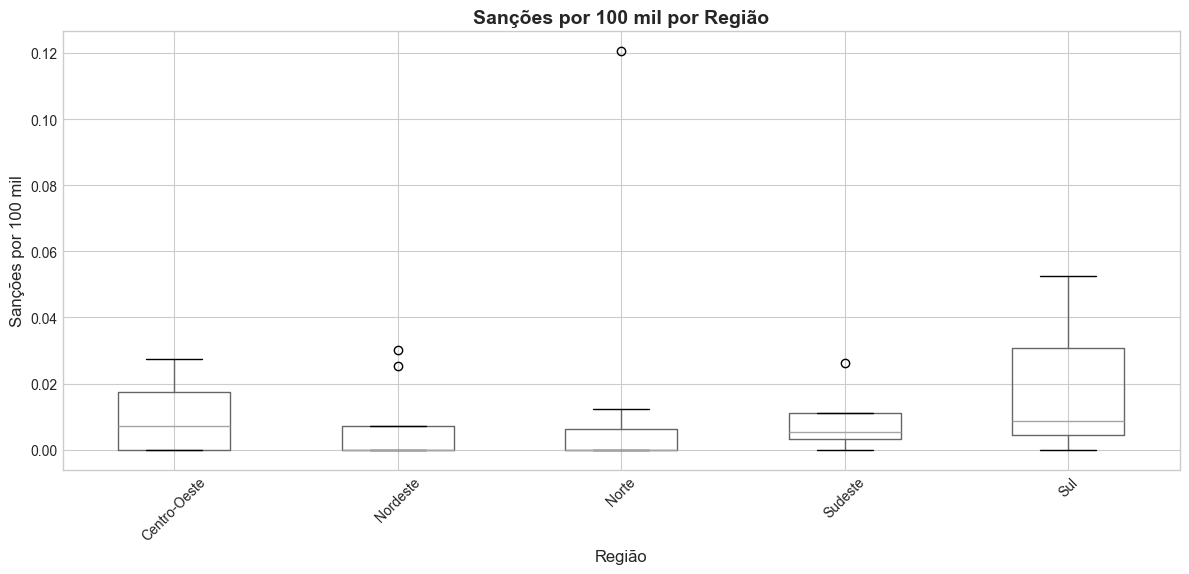

In [84]:
plt.figure(figsize=(12, 6))
df.boxplot(column='sanctions_per_100k', by='region_name', ax=plt.gca())
plt.title('Sanções por 100 mil por Região', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Região', fontsize=12)
plt.ylabel('Sanções por 100 mil', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Testes Post-hoc (Tukey HSD)

Teste Post-hoc Tukey HSD
    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1     group2  meandiff p-adj   lower  upper  reject
-----------------------------------------------------------
Centro-Oeste Nordeste  -0.0034 0.9995 -0.0512 0.0444  False
Centro-Oeste    Norte   0.0086 0.9853 -0.0413 0.0585  False
Centro-Oeste  Sudeste  -0.0012    1.0 -0.0574 0.0551  False
Centro-Oeste      Sul   0.0101 0.9874 -0.0507 0.0708  False
    Nordeste    Norte    0.012 0.8979 -0.0281 0.0521  False
    Nordeste  Sudeste   0.0022 0.9999 -0.0456 0.0501  False
    Nordeste      Sul   0.0135  0.941 -0.0396 0.0665  False
       Norte  Sudeste  -0.0098 0.9765 -0.0597 0.0401  False
       Norte      Sul   0.0015    1.0 -0.0535 0.0564  False
     Sudeste      Sul   0.0112  0.981 -0.0495  0.072  False
-----------------------------------------------------------


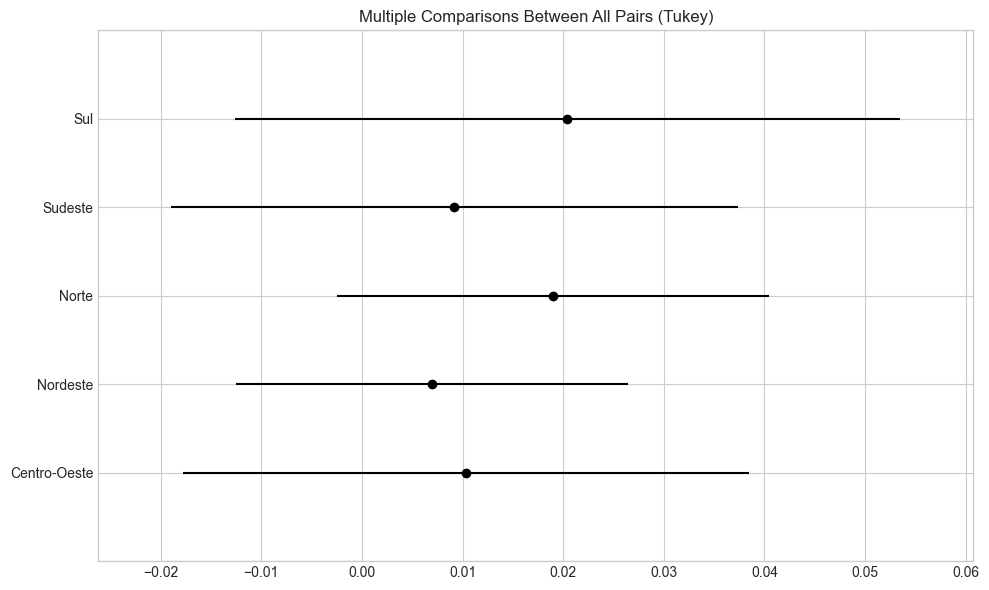

In [85]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['sanctions_per_100k'], 
                          groups=df['region_name'], 
                          alpha=0.05)

print("Teste Post-hoc Tukey HSD")
print("=" * 80)
print(tukey)

tukey.plot_simultaneous()
plt.tight_layout()
plt.show()

## 4. Regressão Linear Múltipla

### 4.1 Especificação do Modelo

In [86]:
y = df['sanctions_per_100k']

X_vars = ['log_income', 'avg_literacy_rate', 'log_population', 
          'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

# Converter para float para evitar problemas de tipo com statsmodels
X = df[X_vars].copy().astype(float)
X = sm.add_constant(X)

print("Especificação do Modelo:")
print("=" * 70)
print(f"Variável Dependente: sanctions_per_100k")
print(f"Variáveis Independentes: {X_vars}")
print(f"\nTamanho da amostra: {len(X)}")
print(f"Número de preditores: {len(X_vars)}")

Especificação do Modelo:
Variável Dependente: sanctions_per_100k
Variáveis Independentes: ['log_income', 'avg_literacy_rate', 'log_population', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

Tamanho da amostra: 27
Número de preditores: 7


### 4.2 Regressão MQO (Mínimos Quadrados Ordinários)

In [87]:
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     sanctions_per_100k   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     1.036
Date:                Mon, 09 Feb 2026   Prob (F-statistic):              0.439
Time:                        03:01:13   Log-Likelihood:                 65.835
No. Observations:                  27   AIC:                            -115.7
Df Residuals:                      19   BIC:                            -105.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.3793      0.25

### 4.3 Interpretação dos Coeficientes

In [88]:
coef_df = pd.DataFrame({
    'Variável': model.params.index,
    'Coeficiente': model.params.values,
    'Erro Padrão': model.bse.values,
    'Estatística-t': model.tvalues.values,
    'Valor-p': model.pvalues.values,
    'IC Inferior': model.conf_int()[0].values,
    'IC Superior': model.conf_int()[1].values
})

coef_df['Significativo'] = coef_df['Valor-p'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

print("\nCoeficientes de Regressão")
print("=" * 100)
display(coef_df.round(4))


Coeficientes de Regressão


,Variável,Coeficiente,Erro Padrão,Estatística-t,Valor-p,IC Inferior,IC Superior,Significativo
0,const,0.3793,0.2557,1.4833,0.1544,-0.1559,0.9145,ns
1,log_income,0.0444,0.0402,1.1027,0.2839,-0.0399,0.1286,ns
2,avg_literacy_rate,-0.0068,0.0033,-2.0519,0.0542,-0.0138,0.0001,ns
3,log_population,-0.0035,0.0078,-0.4481,0.6591,-0.0197,0.0128,ns
4,is_norte,-0.0110,0.0277,-0.3959,0.6966,-0.0690,0.0471,ns
5,is_nordeste,-0.0727,0.0352,-2.0623,0.0531,-0.1465,0.0011,ns
6,is_sul,0.0100,0.0207,0.4816,0.6356,-0.0333,0.0532,ns
7,is_centro_oeste,-0.0140,0.0214,-0.6529,0.5216,-0.0589,0.0309,ns


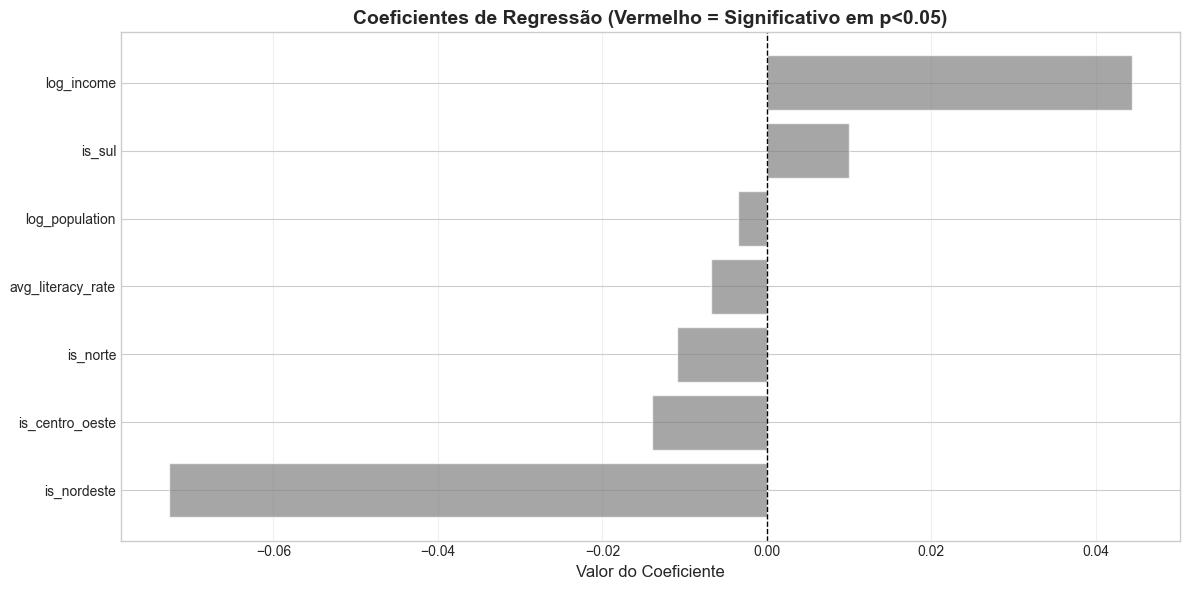

In [89]:
fig, ax = plt.subplots(figsize=(12, 6))

coef_plot = coef_df[coef_df['Variável'] != 'const'].copy()
coef_plot = coef_plot.sort_values('Coeficiente')

colors = ['red' if p < 0.05 else 'gray' for p in coef_plot['Valor-p']]

ax.barh(coef_plot['Variável'], coef_plot['Coeficiente'], color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Valor do Coeficiente', fontsize=12)
ax.set_title('Coeficientes de Regressão (Vermelho = Significativo em p<0.05)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 5. Diagnósticos do Modelo

### 5.1 Análise de Resíduos

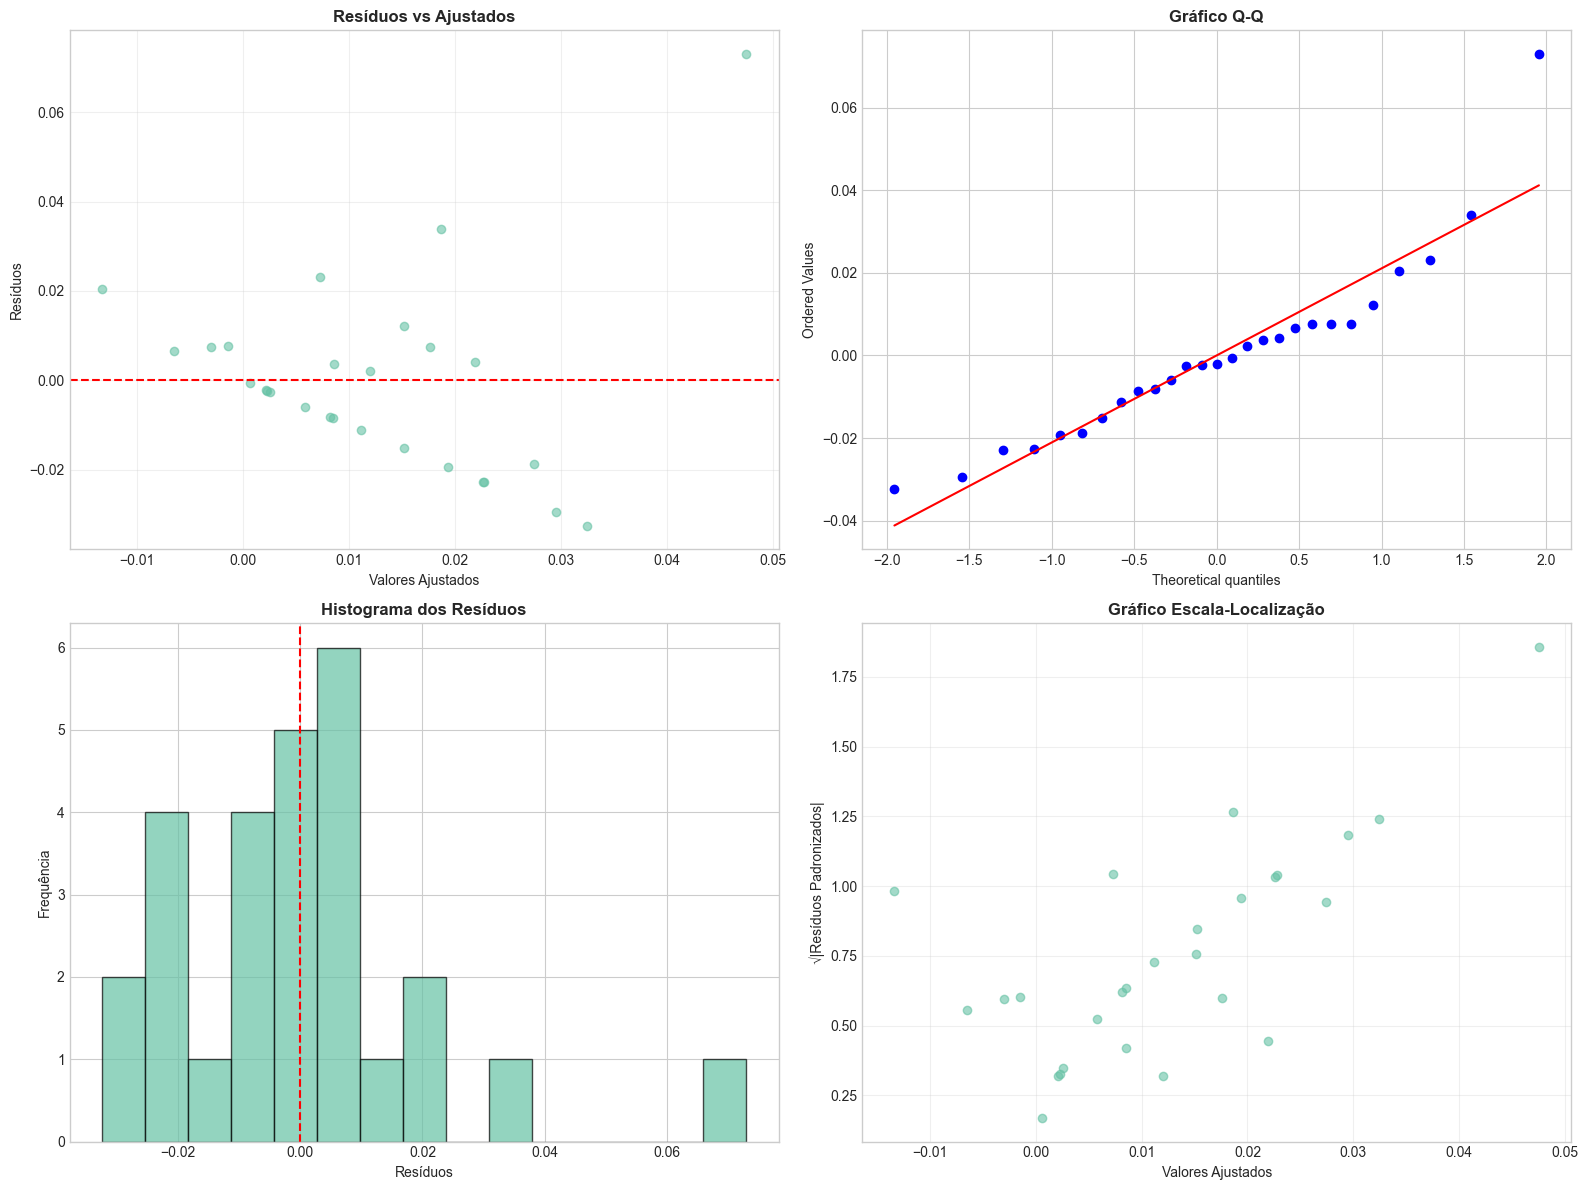

In [90]:
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].scatter(fitted, residuals, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Valores Ajustados')
axes[0, 0].set_ylabel('Resíduos')
axes[0, 0].set_title('Resíduos vs Ajustados', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Gráfico Q-Q', fontweight='bold')

axes[1, 0].hist(residuals, bins=15, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Resíduos')
axes[1, 0].set_ylabel('Frequência')
axes[1, 0].set_title('Histograma dos Resíduos', fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--')

standardized_resid = residuals / np.std(residuals)
axes[1, 1].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6)
axes[1, 1].set_xlabel('Valores Ajustados')
axes[1, 1].set_ylabel('√|Resíduos Padronizados|')
axes[1, 1].set_title('Gráfico Escala-Localização', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Testes de Normalidade

In [91]:
shapiro_stat, shapiro_p = shapiro(residuals)
jb_stat, jb_p = jarque_bera(residuals)

print("Testes de Normalidade dos Resíduos")
print("=" * 70)
print(f"Shapiro-Wilk Test:")
print(f"  Estatística: {shapiro_stat:.4f}")
print(f"  P-value: {shapiro_p:.4f}")
print(f"  Resultado: {'Rejeitar normalidade' if shapiro_p < 0.05 else 'Não pode rejeitar normalidade'}\n")

print(f"Jarque-Bera Test:")
print(f"  Estatística: {jb_stat:.4f}")
print(f"  P-value: {jb_p:.4f}")
print(f"  Resultado: {'Rejeitar normalidade' if jb_p < 0.05 else 'Não pode rejeitar normalidade'}")

Testes de Normalidade dos Resíduos
Shapiro-Wilk Test:
  Estatística: 0.8986
  P-value: 0.0124
  Resultado: Rejeitar normalidade

Jarque-Bera Test:
  Estatística: 19.4349
  P-value: 0.0001
  Resultado: Rejeitar normalidade


### 5.3 Testes de Heterocedasticidade

In [92]:
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X)

print("Testes de Heterocedasticidade")
print("=" * 70)
print(f"Breusch-Pagan Test:")
print(f"  Estatística: {bp_stat:.4f}")
print(f"  P-value: {bp_p:.4f}")
print(f"  Resultado: {'Heterocedasticidade detectada' if bp_p < 0.05 else 'Homocedasticidade (variância constante)'}")

Testes de Heterocedasticidade
Breusch-Pagan Test:
  Estatística: 12.8577
  P-value: 0.0757
  Resultado: Homocedasticidade (variância constante)


### 5.4 Multicolinearidade (VIF)

In [93]:
X_no_const = X.drop('const', axis=1)

vif_data = pd.DataFrame()
vif_data['Variável'] = X_no_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_no_const.values, i) 
                   for i in range(X_no_const.shape[1])]

vif_data['Multicolinearidade'] = vif_data['VIF'].apply(
    lambda x: 'Alto (>10)' if x > 10 else 'Moderado (5-10)' if x > 5 else 'Baixo (<5)'
)

print("Análise do Fator de Inflação da Variância (VIF)")
print("=" * 70)
print("Regra geral: VIF > 10 indica alta multicolinearidade\n")
display(vif_data.sort_values('VIF', ascending=False))

Análise do Fator de Inflação da Variância (VIF)
Regra geral: VIF > 10 indica alta multicolinearidade



,Variável,VIF,Multicolinearidade
1,avg_literacy_rate,3412.2430,Alto (>10)
0,log_income,2672.5161,Alto (>10)
2,log_population,485.9812,Alto (>10)
4,is_nordeste,8.8052,Moderado (5-10)
3,is_norte,3.6843,Baixo (<5)
6,is_centro_oeste,2.8933,Baixo (<5)
5,is_sul,1.9589,Baixo (<5)


### 5.5 Observações Influentes

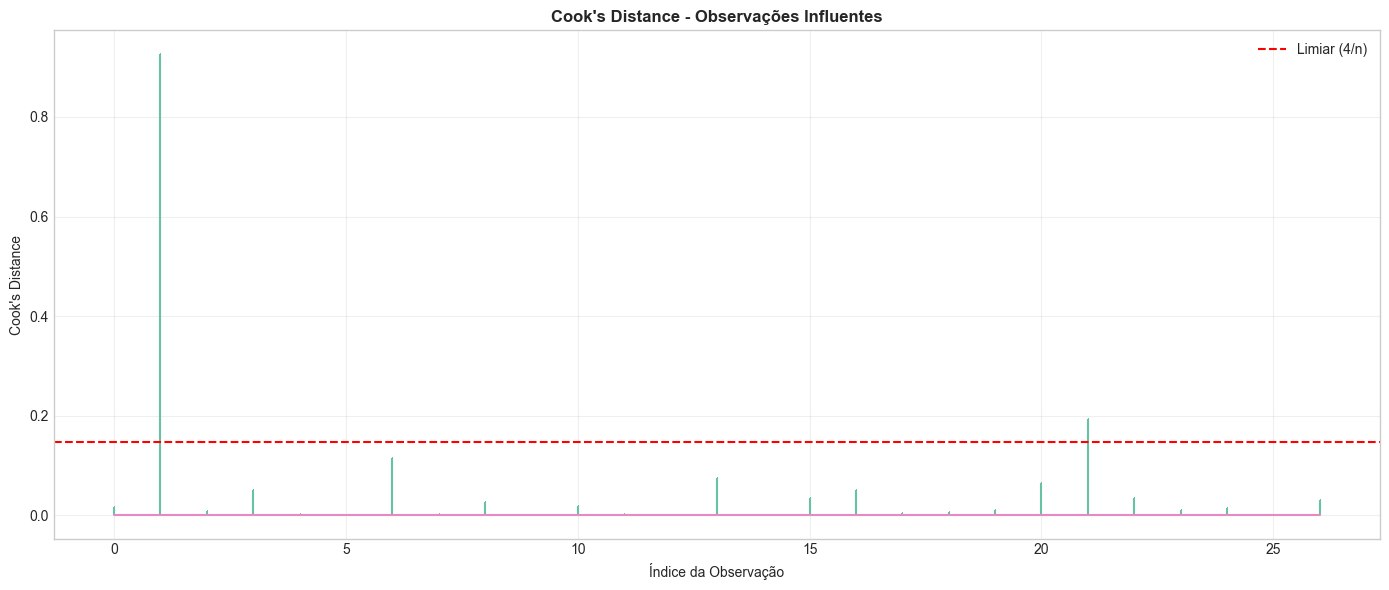


Observações influentes (D de Cook > 0.1481):
        state_name  sanctions_per_100k
1             Acre              0.1205
21  Santa Catarina              0.0526


In [94]:
from statsmodels.stats.outliers_influence import OLSInfluence

influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(figsize=(14, 6))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
ax.axhline(y=4/len(X), color='r', linestyle='--', label='Limiar (4/n)')
ax.set_xlabel('Índice da Observação')
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance - Observações Influentes", fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

threshold = 4 / len(X)
influential = df[cooks_d > threshold][['state_name', 'sanctions_per_100k']]
if len(influential) > 0:
    print(f"\nObservações influentes (D de Cook > {threshold:.4f}):")
    print(influential)
else:
    print("\nNenhuma observação altamente influente detectada.")

## 6. Comparação de Modelos

In [95]:
X_simple = sm.add_constant(df[['log_income', 'avg_literacy_rate']])
model_simple = sm.OLS(y, X_simple).fit()

X_full = X.copy()
model_full = model

comparison = pd.DataFrame({
    'Model': ['Simples (2 vars)', 'Completo (7 vars + regiões)'],
    'R-squared': [model_simple.rsquared, model_full.rsquared],
    'Adj. R-squared': [model_simple.rsquared_adj, model_full.rsquared_adj],
    'AIC': [model_simple.aic, model_full.aic],
    'BIC': [model_simple.bic, model_full.bic],
    'F-statistic': [model_simple.fvalue, model_full.fvalue],
    'Prob (F)': [model_simple.f_pvalue, model_full.f_pvalue]
})

print("Comparação de Modelos")
print("=" * 80)
display(comparison.round(4))

print("\nNota: Menor AIC/BIC indica melhor ajuste do modelo")

Comparação de Modelos


,Model,R-squared,Adj. R-squared,AIC,BIC,F-statistic,Prob (F)
0,Simples (2 vars),0.0025,-0.0806,-117.0099,-113.1224,0.0299,0.9706
1,Completo (7 vars + regiões),0.2762,0.0095,-115.6699,-105.3032,1.0357,0.4394



Nota: Menor AIC/BIC indica melhor ajuste do modelo


## 7. Resumo das Descobertas

**Documente suas descobertas estatísticas:**

### 7.1 Análise de Correlação
- Quais variáveis mostram correlação significativa com sanções?
- Direção e força dos relacionamentos?

### 7.2 Resultados da Regressão
- Quais preditores são estatisticamente significativos?
- Tamanhos de efeito e significância prática?
- Ajuste do modelo (R², R² Ajustado)?

### 7.3 Suposições do Modelo
- Normalidade dos resíduos?
- Homocedasticidade?
- Problemas de multicolinearidade?
- Observações influentes?

### 7.4 Implicações
- O que os resultados nos dizem sobre padrões de compliance?
- Implicações de políticas?
- Limitações e ressalvas?